# Fundamental of Probabilistic Machine Learning: 
# Introduction to Bayesian Inference

---
**file name:** L1_fileB_Fundamentals_Probabilistic_ML.ipynb

Part of Lecture 1 - second notebook

**Instructor**: Alice Cicirello

**Generated for Training school scientific machine learning for digital twins**


**The first draft version of the notebook was generated using Anthropic's Claude**

**Date**: September 2026

**Last Modifications and checks made by Alice Cicirello on: 5/09/2026**

---

**Short description** This notebook is a self-contained introduction to *Bayesian inference*: what
it is, the statistics you need to understand it, how it differs from the *frequentist* approach you
have probably seen in undergraduate courses, and how to actually *do* it on engineering problems.

**Pre-requisites** comfortable with calculus, basic linear algebra, and a little Python. No prior
exposure to probability theory is required — we build it from the ground up.


### Why this notebook?

As engineers we rarely know anything *exactly*. Sensors are noisy, materials vary
batch-to-batch, loads are uncertain, and our models are simplifications of reality.
A prediction such as

> "the fatigue life is 1.2 million cycles"

is far less useful — and far more dangerous — than

> "the fatigue life is $1.2 \pm 0.3$ million cycles (95% interval)."

**Probabilistic Machine Learning (PML)** treats *every* unknown — parameters,
predictions, even the model itself — as a random variable with a probability
distribution. Instead of returning a single number, a probabilistic model returns
a distribution, which lets us answer the questions engineers actually care about:

* How confident is the model? *(uncertainty quantification)*
* What is the probability the design exceeds a safety limit? *(reliability)*
* Where should I place the next expensive experiment? *(optimal design)*
* Is this new measurement an anomaly? *(condition monitoring / SHM)*

### Roadmap

| Part | Topic | What you'll learn |
|------|-------|-------------------|
| 1 | Fundamentals of probability | Sampling, Bayes' rule, the Gaussian |
| 2 | Two philosophies: |  frequentist vs. Bayesian |
| 3 | The probabilistic view of learning | Likelihood, MLE, MAP, priors |
| 4 | Bayesian Linear Regression | deriving a full posterior *by hand*, in NumPy |

Everything runs with only `numpy`, `scipy`, `matplotlib`, and `scikit-learn`.


In [1]:
# Setup ---------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)          # reproducible randomness

plt.rcParams.update({
    "figure.figsize": (9, 4.2),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Ready. NumPy", np.__version__)

Ready. NumPy 2.3.5


## Part 1 — Fundamentals of Probability

### 1.1 Random variables and distributions

A **random variable** $X$ maps outcomes of a random experiment to numbers. We
distinguish:

* **Discrete** $X$ — takes countable values; described by a **probability mass
  function (PMF)** $p(x)=P(X=x)$, with $\sum_x p(x)=1$.
* **Continuous** $X$ — takes values on $\mathbb{R}$; described by a **probability
  density function (PDF)** $p(x)\ge 0$, with $\int_{-\infty}^{\infty} p(x)\,dx = 1$.
  Here $p(x)$ is a *density*, not a probability: probabilities come from areas,
  $P(a\le X\le b)=\int_a^b p(x)\,dx$.

The **cumulative distribution function (CDF)** is $F(x) = P(X \le x)$.

> ⚠️ For a continuous RV, $p(x)$ is a *density*, not a probability: $p(x)$ can exceed 1, and
> $P(X = x) = 0$ for any single point. Probabilities come from *areas*: $P(a \le X \le b)=\int_a^b f\,dx$.

- The **sample space** $\Omega$ is the set of all possible outcomes of an experiment
  (e.g. for a fatigue test, $\Omega$ = all possible cycles-to-failure).
- An **event** $A \subseteq \Omega$ is a subset of outcomes (e.g. "failure before $10^6$ cycles").
- A **probability** $P$ assigns a number to each event, obeying **Kolmogorov's axioms**:

$$
\text{(1)}\;\; P(A) \ge 0, \qquad
\text{(2)}\;\; P(\Omega) = 1, \qquad
\text{(3)}\;\; P\!\Big(\bigcup_i A_i\Big) = \sum_i P(A_i)\ \text{ for disjoint } A_i .
$$

Everything in probability — and therefore in Bayesian inference — follows from these three rules.

### 1.2 Expectation, variance, covariance

The **expectation** (mean) and **variance** summarise a distribution:

$$
\mathbb{E}[X]=\mu=\int x\,p(x)\,dx, \qquad
\operatorname{Var}[X]=\sigma^2=\mathbb{E}\!\big[(X-\mu)^2\big].
$$

The **standard deviation** $\sigma=\sqrt{\operatorname{Var}[X]}$ has the same units as $X$ and
measures spread. 

**Note**: just Replace $\int$ with $\sum$ for discrete RVs!

For two variables the **covariance** and **correlation** measure linear
co-variation:

$$
\operatorname{Cov}[X,Y]=\mathbb{E}\big[(X-\mu_X)(Y-\mu_Y)\big],\qquad
\rho_{XY}=\frac{\operatorname{Cov}[X,Y]}{\sigma_X\sigma_Y}\in[-1,1].
$$


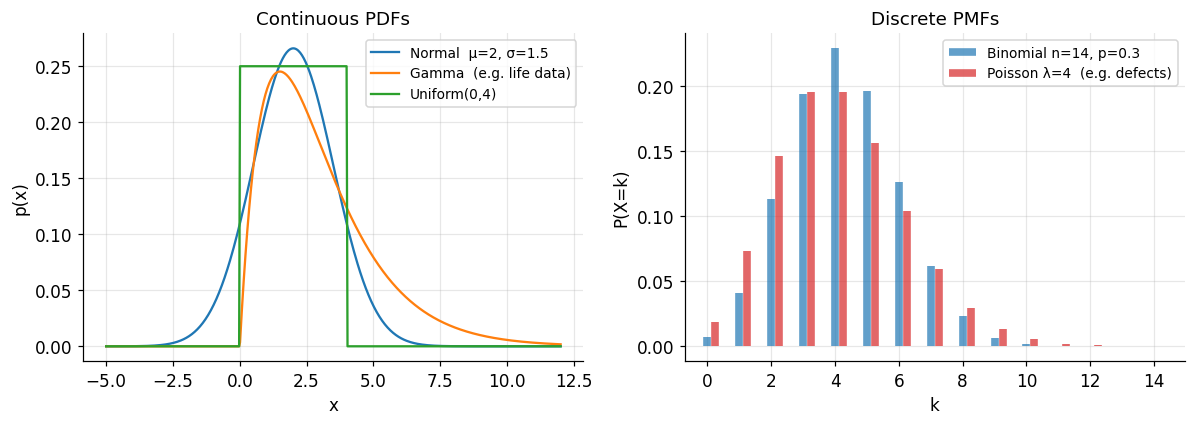

In [2]:
# A few named distributions engineers meet constantly --------------------
x = np.linspace(-5, 12, 500)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Continuous PDFs
ax[0].plot(x, stats.norm(2, 1.5).pdf(x), label="Normal  μ=2, σ=1.5")
ax[0].plot(x, stats.gamma(a=2, scale=1.5).pdf(x), label="Gamma  (e.g. life data)")
ax[0].plot(x, stats.uniform(0, 4).pdf(x), label="Uniform(0,4)")
ax[0].set(title="Continuous PDFs", xlabel="x", ylabel="p(x)")
ax[0].legend(fontsize=9)

# Discrete PMFs
k = np.arange(0, 15)
ax[1].vlines(k, 0, stats.binom(14, 0.3).pmf(k), color="C0", lw=5, alpha=.7,
             label="Binomial n=14, p=0.3")
ax[1].vlines(k+0.25, 0, stats.poisson(4).pmf(k), color="C3", lw=5, alpha=.7,
             label="Poisson λ=4  (e.g. defects)")
ax[1].set(title="Discrete PMFs", xlabel="k", ylabel="P(X=k)")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

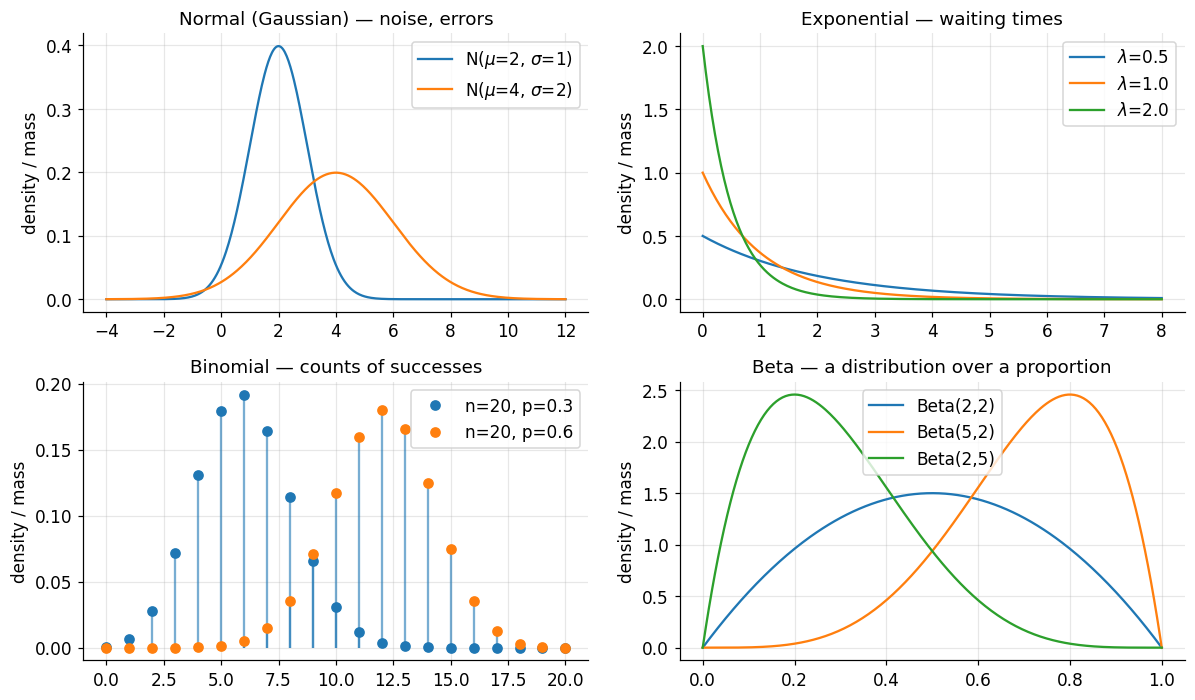

In [3]:
# A quick tour of common distributions used throughout engineering statistics.
x = np.linspace(-4, 12, 500)
fig, ax = plt.subplots(2, 2, figsize=(11, 6.5))

# Gaussian / Normal  ~ measurement noise, sums of many small effects (CLT)
for mu, sd in [(2, 1), (4, 2)]:
    ax[0,0].plot(x, stats.norm.pdf(x, mu, sd), label=f"N($\\mu$={mu}, $\\sigma$={sd})")
ax[0,0].set_title("Normal (Gaussian) — noise, errors"); ax[0,0].legend()

# Exponential ~ time-to-event, memoryless failures
xe = np.linspace(0, 8, 300)
for lam in [0.5, 1.0, 2.0]:
    ax[0,1].plot(xe, stats.expon.pdf(xe, scale=1/lam), label=f"$\\lambda$={lam}")
ax[0,1].set_title("Exponential — waiting times"); ax[0,1].legend()

# Binomial ~ number of successes in n trials (discrete)
k = np.arange(0, 21)
for n, p in [(20, 0.3), (20, 0.6)]:
    ax[1,0].vlines(k, 0, stats.binom.pmf(k, n, p), alpha=0.6)
    ax[1,0].plot(k, stats.binom.pmf(k, n, p), "o", label=f"n={n}, p={p}")
ax[1,0].set_title("Binomial — counts of successes"); ax[1,0].legend()

# Beta ~ a distribution OVER a probability (0..1); we will use it a lot
xb = np.linspace(0, 1, 300)
for a, b in [(2, 2), (5, 2), (2, 5)]:
    ax[1,1].plot(xb, stats.beta.pdf(xb, a, b), label=f"Beta({a},{b})")
ax[1,1].set_title("Beta — a distribution over a proportion"); ax[1,1].legend()

for a in ax.ravel(): a.set_ylabel("density / mass")
fig.tight_layout(); plt.show()

### 1.3 The Law of Large Numbers and the Central Limit Theorem (CLT)

Two theorems justify why we can *estimate* probabilities from data and why the
Gaussian is everywhere:

* **Law of Large Numbers (LLN):** the sample mean $\bar X_n \to \mu$ as $n\to\infty$.
* **Central Limit Theorem (CLT):** the sum/mean of many independent random
  effects is approximately Gaussian, *regardless of the individual
  distributions*. This is why measurement noise — the addition of many small
  independent errors — is so often modelled as Gaussian.


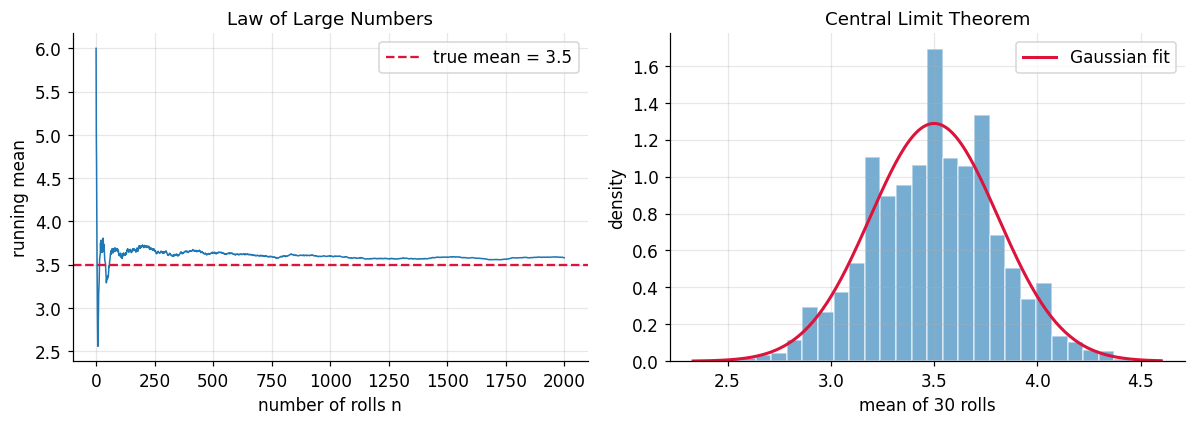

Mean of sample means = 3.500  (theory 3.500)
Std  of sample means = 0.310  (theory 0.312)


In [4]:
# LLN: running mean of dice rolls converges to the true mean 3.5

rolls = rng.integers(1, 7, size=2000)
running_mean = np.cumsum(rolls) / np.arange(1, len(rolls)+1)

# CLT: distribution of the *mean of 30 rolls*, repeated 5000 times, looks Gaussian
means = rng.integers(1, 7, size=(5000, 30)).mean(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(running_mean, lw=1)
ax[0].axhline(3.5, color="crimson", ls="--", label="true mean = 3.5")
ax[0].set(xlabel="number of rolls n", ylabel="running mean", title="Law of Large Numbers")
ax[0].legend()

ax[1].hist(means, bins=30, density=True, alpha=0.6, edgecolor="white")
mu, sd = means.mean(), means.std()
xs = np.linspace(means.min(), means.max(), 200)
ax[1].plot(xs, stats.norm.pdf(xs, mu, sd), "crimson", lw=2, label="Gaussian fit")
ax[1].set(xlabel="mean of 30 rolls", ylabel="density", title="Central Limit Theorem")
ax[1].legend()
fig.tight_layout(); plt.show()
print(f"Mean of sample means = {mu:.3f}  (theory 3.500)")
print(f"Std  of sample means = {sd:.3f}  (theory {np.sqrt((35/12)/30):.3f})")

### 1.4 Joint, marginal and conditional probability — the two rules that run everything

Almost all of probabilistic ML relies on just **two rules**:

$$
\textbf{Sum rule:}\quad p(x)=\sum_{y} p(x,y)\quad\Big(\text{or } \int p(x,y)\,dy\Big)
$$
$$
\textbf{Product rule:}\quad p(x,y)=p(x\mid y)\,p(y)=p(y\mid x)\,p(x)
$$

* $p(x,y)$ — **joint**: probability of $x$ *and* $y$ together.
* $p(x)$ — **marginal**: "integrate out" what you don't care about (sum rule).
* $p(x\mid y)$ — **conditional**: probability of $x$ *given* you observed $y$.

Two variables are **independent** iff $p(x,y)=p(x)p(y)$.

Therefore, when two RVs $X, Y$ interact we need:

$$
\underbrace{p(x,y)}_{\text{joint}}, \qquad
\underbrace{p(x)=\textstyle\sum_y p(x,y)}_{\text{marginal (sum/integrate out }y)}, \qquad
\underbrace{p(x\mid y)=\dfrac{p(x,y)}{p(y)}}_{\text{conditional}} .
$$

The **conditional** $p(x\mid y)$ reads "the distribution of $X$ *given that* we know $Y=y$".
Rearranging the definition gives the **product (chain) rule**:

$$
p(x, y) = p(x \mid y)\, p(y) = p(y \mid x)\, p(x).
$$

$X$ and $Y$ are **independent** iff $p(x,y)=p(x)p(y)$, equivalently $p(x\mid y)=p(x)$ — knowing
$Y$ tells you nothing about $X$. 

Setting the two factorisations of $p(x,y)$ equal is *exactly*
what gives us Bayes' theorem 

$$
 p(x \mid y) =\dfrac{ p(y \mid x)\, p(x)} {p(y)} 
$$

### 1.5 Bayes' Theorem — learning from data

We has seen that rearranging the product rule ($p(x\mid y)p(y)=p(y\mid x)p(x)$) gives the single most
important equation in this notebook, that can be expressed as:

$$
\boxed{\;p(\theta\mid \mathcal{D}) \;=\; \frac{p(\mathcal{D}\mid \theta)\,p(\theta)}{p(\mathcal{D})}\;}
$$

$$
\underbrace{p(\theta\mid\mathcal D)}_{\text{posterior}}\ \propto\
\underbrace{p(\mathcal D\mid\theta)}_{\text{likelihood}}\ \times\
\underbrace{p(\theta)}_{\text{prior}},
\qquad
p(\mathcal D)=\!\int\! p(\mathcal D\mid\theta)p(\theta)\,d\theta \;\;(\text{evidence}).
$$

Read it as an *update*: 

your **prior** belief about unknown parameters $\theta$,

combined with the **likelihood** of the observed data $\mathcal D$ (that must be informative on the parameter  $\theta$),

yields an updated **posterior** belief.

This is the engine of Bayesian machine learning! 

Note: We are inherently assuming that both the Data and the parameters are random variables! This is a fundamental assumption in the subjective interpretation of probability... infact we talk about **belief**!  (More will be said about this in section 2 of this notebook)

What are these?
- **Prior** $p(\theta)$ — what we believe about $\theta$ *before* seeing the data.
- **Likelihood** $p(\mathcal{D}\mid\theta)$ — how well a given $\theta$ explains the data.
- **Evidence** $p(\mathcal{D}) = \int p(\mathcal{D}\mid\theta)\,p(\theta)\,d\theta$ — a normalising
  constant ensuring the posterior integrates to 1. It's the hard bit (an integral over *all* $\theta$).
- **Posterior** $p(\theta\mid\mathcal{D})$ — our updated belief. **This is the goal of inference.*

### 1.6 The proportional form that is at the core of Bayesian Inference
Because the evidence does not depend on $\theta$, for the *shape* of the posterior we can drop it:

$$
\boxed{\; p(\theta\mid\mathcal{D}) \;\propto\; p(\mathcal{D}\mid\theta)\; p(\theta) \;}
\qquad\Longleftrightarrow\qquad
\textbf{posterior} \;\propto\; \textbf{likelihood} \times \textbf{prior}.
$$

**Bayesian learning is iterative:** today's posterior becomes tomorrow's prior. Observe more data
and just multiply by the new likelihood. 

#### 1.6.1 Bayes' theorem worked example: is a component defective? - discrete variables

In [5]:
# Bayes' theorem worked example: is a component defective? ------------------
# A non-destructive test flags defects. Base rate of defects P(D)=2%.
# Test sensitivity P(+|D)=95%, false-positive rate P(+|not D)=8%.
# A part tests POSITIVE. What is P(defective | +)?
p_D      = 0.02            # prior
p_pos_D  = 0.95            # likelihood if defective
p_pos_nD = 0.08            # likelihood if healthy

# Evidence (sum rule): P(+) = P(+|D)P(D) + P(+|not D)P(not D)
p_pos = p_pos_D*p_D + p_pos_nD*(1-p_D)
p_D_pos = p_pos_D*p_D / p_pos     # Bayes' theorem

print(f"Prior  P(defective)          = {p_D:6.2%}")
print(f"Evidence P(test positive)    = {p_pos:6.2%}")
print(f"Posterior P(defective | +)   = {p_D_pos:6.2%}")
print("\nLesson: even a 95%-accurate test gives only a ~20% posterior,")
print("because defects are rare. Priors matter — intuition often fails here.")

Prior  P(defective)          =  2.00%
Evidence P(test positive)    =  9.74%
Posterior P(defective | +)   = 19.51%

Lesson: even a 95%-accurate test gives only a ~20% posterior,
because defects are rare. Priors matter — intuition often fails here.


### 1.7 The Gaussian distribution — the workhorse

The **Gaussian (Normal)** distribution is central to PML because it is 

(a) produced by the CLT, 

(b) fully described by just a mean and (co)variance, 

(c) closed under the operations we need (conditioning, marginalising, linear maps all stay Gaussian).


**Univariate:**
$$
\mathcal N(x\mid \mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\Big(-\frac{(x-\mu)^2}{2\sigma^2}\Big).
$$

**Multivariate** (dimension $d$), with mean vector $\boldsymbol\mu$ and covariance
matrix $\boldsymbol\Sigma$:
$$
\mathcal N(\mathbf x\mid \boldsymbol\mu,\boldsymbol\Sigma)=
\frac{1}{(2\pi)^{d/2}|\boldsymbol\Sigma|^{1/2}}
\exp\!\Big(-\tfrac12(\mathbf x-\boldsymbol\mu)^{\!\top}\boldsymbol\Sigma^{-1}(\mathbf x-\boldsymbol\mu)\Big).
$$

**Note** that Gaussian Process are based on the concept that: if $\begin{bmatrix}\mathbf x_1\\\mathbf x_2\end{bmatrix}$
is jointly Gaussian, then both the **marginal** $p(\mathbf x_1)$ and the
**conditional** $p(\mathbf x_1\mid \mathbf x_2)$ are again Gaussian, with closed-form
mean and covariance.

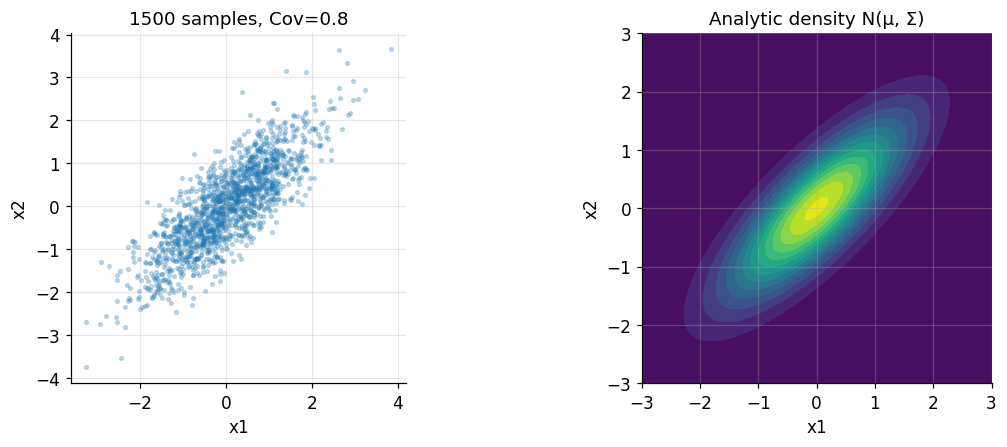

In [6]:
# Visualise a 2-D Gaussian: correlation shows up as a tilted ellipse ---------
mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.8],
                  [0.8, 1.0]])          # correlation = 0.8

samples = rng.multivariate_normal(mu, Sigma, size=1500)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
# scatter of samples
ax[0].scatter(samples[:,0], samples[:,1], s=6, alpha=.25)
ax[0].set(title="1500 samples, Cov=0.8", xlabel="x1", ylabel="x2", aspect="equal")

# analytic density contours
gx, gy = np.mgrid[-3:3:120j, -3:3:120j]
pos = np.dstack((gx, gy))
dens = stats.multivariate_normal(mu, Sigma).pdf(pos)
ax[1].contourf(gx, gy, dens, levels=15, cmap="viridis")
ax[1].set(title="Analytic density N(μ, Σ)", xlabel="x1", ylabel="x2", aspect="equal")
plt.tight_layout(); plt.show()

## 2. Two philosophies: frequentist vs. Bayesian
Both schools **use the same probability axioms**, but they **disagree** on what probability means.

- **Frequentist:** probability is the *long-run relative frequency* of an event over infinitely
  many repetitions. "The probability this component fails is 0.01" means *1 in 100 identical
  components fail over the long run*.
- **Bayesian:** probability is a *degree of belief*, a quantified state of knowledge that can be
  updated by evidence. It applies even to one-off events ("the probability *this bridge design*meets code"), where "repetition" is meaningless.

### 2.1 What is random?

Suppose we want to identify the unknown parameter $\theta$ (say, the true stiffness of a batch
of beams).

| | Data $\mathcal{D}$ | Parameter $\theta$ |
|---|---|---|
| **Frequentist** | random | **fixed** but unknown constant |
| **Bayesian** | random (but, once observed, conditioned on) | **random** — described by a probability distribution encoding our uncertainty |

The Bayesian treats *our uncertainty about* $\theta$ as a probability distribution. That single move
is what lets us write $p(\theta \mid \mathcal{D})$ — a phrase a strict frequentist regards as
meaningless, because to them $\theta$ is not a random variable.

### 2.2 Point estimation: MLE vs. MAP

The **likelihood** $\;\mathcal{L}(\theta) = p(\mathcal{D}\mid\theta)\;$ is the probability of the
observed data as a function of the parameter. Both schools use it.

- **Frequentist — Maximum Likelihood Estimate (MLE):** pick the $\theta$ that makes the data most
  probable.
$$ \hat\theta_{\text{MLE}} = \arg\max_\theta\; p(\mathcal{D}\mid\theta). $$

- **Bayesian — Maximum A Posteriori (MAP):** pick the **peak of the *posterior***.
$$ \hat\theta_{\text{MAP}} = \arg\max_\theta\; p(\mathcal{D}\mid\theta)\,p(\theta). $$

With a flat (uniform) prior, MAP = MLE. So MLE is a special case of Bayesian estimation with "no
prior opinion". But the Bayesian keeps the *whole* posterior distribution, not just its peak — that
is where uncertainty quantification comes from.

### 2.3 Confidence interval vs. credible interval — a subtle but crucial difference

This is the most commonly misunderstood point in all of statistics.

- A **95% confidence interval** (frequentist) is a *random interval* produced by a procedure that,
  *over many repeated experiments*, contains the fixed true $\theta$ 95% of the time. For your one
  computed interval $[a,b]$, it is **wrong** to say "there is a 95% probability $\theta$ is in
  $[a,b]$" — $\theta$ is fixed, so it is either in or out.
- A **95% credible interval** (Bayesian):
$$ P(\theta \in [a, b] \mid \mathcal{D}) = 0.95, $$
  i.e. given the data and prior, there is a 95% probability $\theta$ lies in $[a,b]$.


## Part 3 — The Probabilistic View of Learning

### 3.1 Likelihood and Maximum Likelihood Estimation (MLE) in action 

Suppose data $\mathcal D=\{y_i\}_{i=1}^N$ are modelled as i.i.d. (independent and identically distributed) draws from a
distribution with parameters $\theta$. 

The **likelihood** is the probability of the
data seen *as a function of $\theta$*:

$$
p(\mathcal D\mid\theta)=\prod_{i=1}^N p(y_i\mid\theta).
$$

**Maximum Likelihood** picks the $\theta$ that makes the observed data most probable.

Because products of small numbers underflow, we maximise the **log-likelihood**:

$$
\hat\theta_{\text{MLE}}=\arg\max_\theta \sum_{i=1}^N \log p(y_i\mid\theta).
$$

A key engineering insight: **least-squares fitting is MLE under Gaussian noise.** If
$y_i=f(x_i)+\varepsilon_i$ with $\varepsilon_i\sim\mathcal N(0,\sigma^2)$, then
maximising the likelihood is *identical* to minimising $\sum_i (y_i-f(x_i))^2$.

### 3.2 From MLE to MAP — adding a prior (and getting regularisation for free)

MLE has no notion of prior belief and over-fits with little data. **Maximum a
Posteriori (MAP)** multiplies in a prior $p(\theta)$:

$$
\hat\theta_{\text{MAP}}=\arg\max_\theta\ \big[\log p(\mathcal D\mid\theta)+\log p(\theta)\big].
$$

With a Gaussian prior $\theta\sim\mathcal N(0,\tau^2 I)$ this becomes **ridge
regression (L2 regularisation)**; a Laplace prior gives **LASSO (L1)**. So
regularisation is not an arbitrary trick — it is a *prior belief that parameters
should be small*.

> **The Bayesian step beyond MAP:** MLE and MAP still return a single best $\theta$
> (a *point estimate*). Full Bayesian inference keeps the **entire posterior
> distribution** $p(\theta\mid\mathcal D)$ — that is what delivers honest uncertainty,
> and it is what we do next.


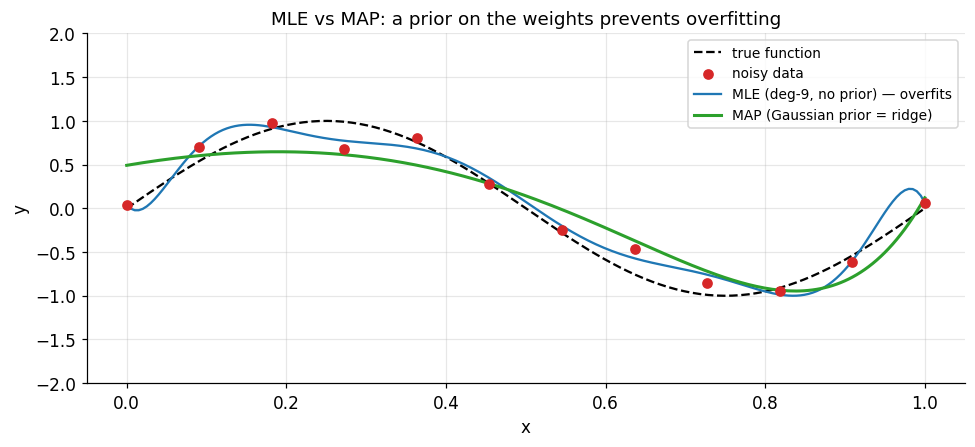

In [7]:
# Demonstrate MLE = least squares, and how a prior (MAP) tames overfitting ----
np.random.seed(1)
x = np.linspace(0, 1, 12)
true = lambda t: np.sin(2*np.pi*t)
y = true(x) + rng.normal(0, 0.18, size=x.size)

xg = np.linspace(0, 1, 200)
deg = 9                                   # deliberately over-flexible polynomial
Phi   = np.vander(x,  deg+1, increasing=True)
Phi_g = np.vander(xg, deg+1, increasing=True)

# MLE (ordinary least squares) -- over-fits wildly
w_mle = np.linalg.lstsq(Phi, y, rcond=None)[0]

# MAP (ridge): add lambda*I  <=> Gaussian prior on weights
lam = 1e-2
w_map = np.linalg.solve(Phi.T@Phi + lam*np.eye(deg+1), Phi.T@y)

plt.figure(figsize=(9,4.2))
plt.plot(xg, true(xg), "k--", label="true function")
plt.scatter(x, y, c="C3", zorder=5, label="noisy data")
plt.plot(xg, Phi_g@w_mle, "C0", label="MLE (deg-9, no prior) — overfits")
plt.plot(xg, Phi_g@w_map, "C2", lw=2, label="MAP (Gaussian prior = ridge)")
plt.ylim(-2, 2); plt.legend(fontsize=9)
plt.title("MLE vs MAP: a prior on the weights prevents overfitting")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

## Part 4 — Bayesian Linear Regression (a full posterior, by hand)

We now do a *complete* Bayesian treatment of a model that engineers use daily.
Because everything is Gaussian and linear, we can write the answer in closed form —
no sampling required — which makes it the perfect first Bayesian model.

### 4.1 The model

We fit $y=\mathbf w^\top\boldsymbol\phi(x)+\varepsilon$ where $\boldsymbol\phi(x)$ is a
fixed set of **basis functions** (polynomials, sinusoids, radial bumps, …). Model is
linear *in the weights* $\mathbf w$, not necessarily in $x$.

* **Likelihood** (Gaussian noise, precision $\beta=1/\sigma^2$):
  $\;p(\mathbf y\mid\mathbf w)=\mathcal N(\mathbf y\mid \boldsymbol\Phi\mathbf w,\ \beta^{-1}\mathbf I)$
* **Prior** on weights: $\;p(\mathbf w)=\mathcal N(\mathbf w\mid \mathbf 0,\ \alpha^{-1}\mathbf I)$

### 4.2 The posterior (closed form)

Gaussian prior $\times$ Gaussian likelihood $=$ Gaussian posterior
$p(\mathbf w\mid\mathbf y)=\mathcal N(\mathbf w\mid\mathbf m_N,\mathbf S_N)$ with
*(Bishop 2006, Eq. 3.53–3.54)*:

$$
\mathbf S_N^{-1}=\alpha\mathbf I+\beta\,\boldsymbol\Phi^\top\boldsymbol\Phi,
\qquad
\mathbf m_N=\beta\,\mathbf S_N\,\boldsymbol\Phi^\top\mathbf y.
$$

### 4.3 The predictive distribution — where uncertainty comes from

For a new input $x_\*$ we don't just plug in $\mathbf m_N$; we *integrate over all
plausible weights*:

$$
p(y_\*\mid x_\*,\mathbf y)=\int p(y_\*\mid\mathbf w)\,p(\mathbf w\mid\mathbf y)\,d\mathbf w
=\mathcal N\!\big(y_\*\mid \mathbf m_N^\top\boldsymbol\phi_\*,\ \sigma_N^2(x_\*)\big),
$$
$$
\sigma_N^2(x_\*)=\underbrace{\beta^{-1}}_{\text{aleatoric (noise)}}
+\underbrace{\boldsymbol\phi_\*^\top \mathbf S_N\,\boldsymbol\phi_\*}_{\text{epistemic (model)}}.
$$

This split is the payoff of going Bayesian:

* **Aleatoric** uncertainty — irreducible measurement noise ($\beta^{-1}$). More data
  won't remove it.
* **Epistemic** uncertainty — our ignorance about $\mathbf w$. It *shrinks where we
  have data* and *grows where we extrapolate*. This is exactly the behaviour a
  safety-critical model should have.


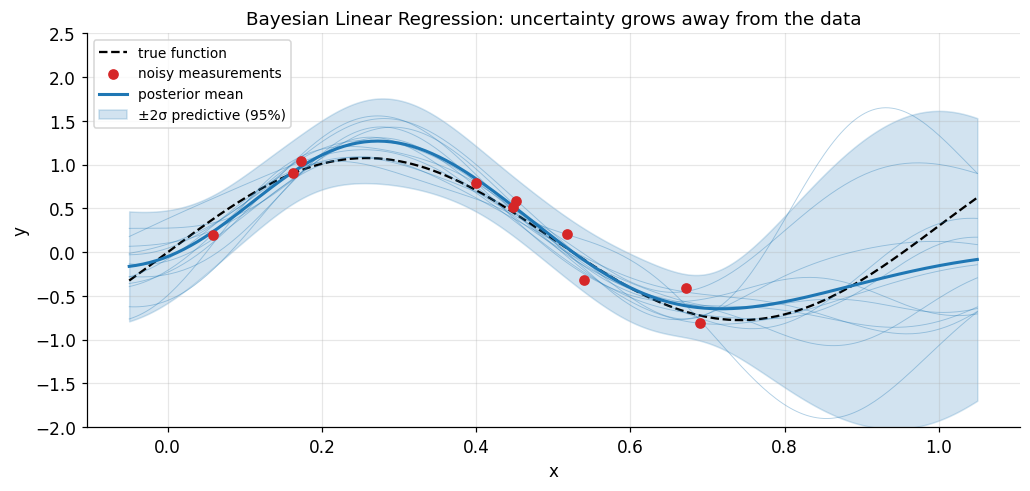

Notice: the band is TIGHT where data live (left) and FANS OUT on the right,
where the model must extrapolate. That widening is epistemic uncertainty.


In [8]:
# Bayesian Linear Regression from scratch, with Gaussian radial basis funcs ----
def rbf_features(x, centers, width):
    """Design matrix of Gaussian bumps + a bias column."""
    x = np.atleast_1d(x)[:, None]
    Phi = np.exp(-0.5*((x - centers[None, :])/width)**2)
    return np.hstack([np.ones((x.shape[0], 1)), Phi])   # prepend bias

# --- synthetic 'experiment': a nonlinear response measured with noise
f_true = lambda x: np.sin(2*np.pi*x) + 0.3*x
N = 10
xd = np.sort(rng.uniform(0.05, 0.75, N))          # data only on the LEFT side
yd = f_true(xd) + rng.normal(0, 0.15, N)          # -> watch the RIGHT extrapolate

centers = np.linspace(0, 1, 9)
width   = 0.12
alpha, beta = 2.0, 1/0.15**2                      # prior precision, noise precision

Phi = rbf_features(xd, centers, width)
SN_inv = alpha*np.eye(Phi.shape[1]) + beta*Phi.T@Phi
SN = np.linalg.inv(SN_inv)
mN = beta * SN @ Phi.T @ yd                        # posterior mean weights

# predictive distribution on a grid
xg = np.linspace(-0.05, 1.05, 250)
Phi_g = rbf_features(xg, centers, width)
mean_g = Phi_g @ mN
var_epi = np.einsum('ij,jk,ik->i', Phi_g, SN, Phi_g)   # epistemic term
var_tot = 1/beta + var_epi                             # + aleatoric
std_g = np.sqrt(var_tot)

plt.figure(figsize=(9.5, 4.6))
plt.plot(xg, f_true(xg), "k--", label="true function")
plt.scatter(xd, yd, c="C3", zorder=5, label="noisy measurements")
plt.plot(xg, mean_g, "C0", lw=2, label="posterior mean")
plt.fill_between(xg, mean_g-2*std_g, mean_g+2*std_g, color="C0", alpha=.2,
                 label="±2σ predictive (95%)")
# draw a few functions sampled from the posterior over weights
for _ in range(12):
    w = rng.multivariate_normal(mN, SN)
    plt.plot(xg, Phi_g @ w, "C0", lw=.6, alpha=.35)
plt.legend(fontsize=9, loc="upper left")
plt.title("Bayesian Linear Regression: uncertainty grows away from the data")
plt.xlabel("x"); plt.ylabel("y"); plt.ylim(-2, 2.5); plt.tight_layout(); plt.show()

print("Notice: the band is TIGHT where data live (left) and FANS OUT on the right,")
print("where the model must extrapolate. That widening is epistemic uncertainty.")

### 4.4 Sequential learning — the posterior *is* the memory

A very useuful property of the Bayesian update: yesterday's posterior becomes today's
prior. As measurements arrive one by one, the posterior contracts around the truth —
a natural model of *learning*. Let's watch the posterior over just two weights
(slope & intercept of a straight line) sharpen as data accumulate.

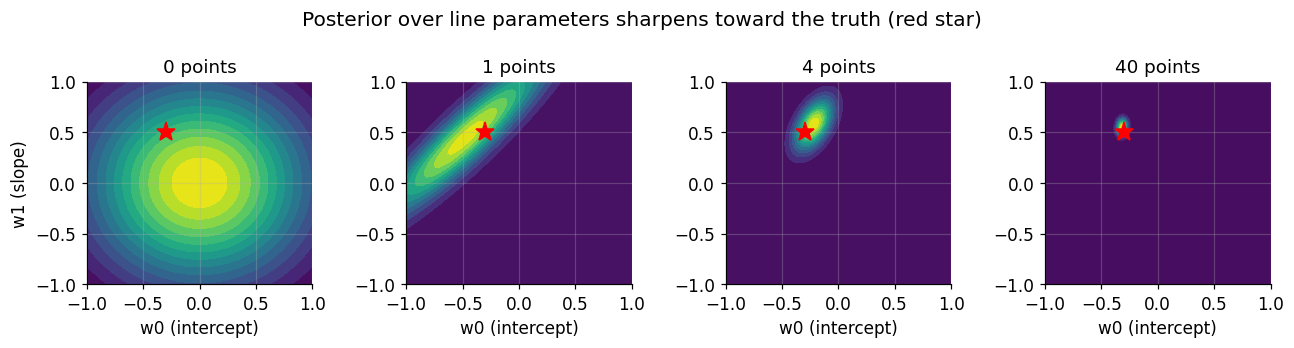

In [9]:
# Sequential Bayesian updating for a straight line y = w0 + w1 x --------------
w_true = np.array([-0.3, 0.5])
xs = rng.uniform(-1, 1, 40)
ys = w_true[0] + w_true[1]*xs + rng.normal(0, 0.2, 40)

a, b = 2.0, 1/0.2**2                       # prior & noise precision
w0g, w1g = np.mgrid[-1:1:120j, -1:1:120j]
grid = np.dstack([w0g, w1g])

def gauss2d(mean, cov):
    return stats.multivariate_normal(mean, cov).pdf(grid)

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
Sinv = a*np.eye(2); Sm = np.zeros(2)       # start from the prior
seen = 0
snapshots = [0, 1, 4, 40]
Phi_all = np.column_stack([np.ones_like(xs), xs])
for ax, n in zip(axes, snapshots):
    if n > 0:
        P = Phi_all[:n]; Y = ys[:n]
        Sinv = a*np.eye(2) + b*P.T@P
        S = np.linalg.inv(Sinv)
        m = b * S @ P.T @ Y
    else:
        S = np.linalg.inv(Sinv); m = Sm
    ax.contourf(w0g, w1g, gauss2d(m, S), levels=14, cmap="viridis")
    ax.plot(*w_true, "r*", ms=13)          # true weights
    ax.set_title(f"{n} points"); ax.set_xlabel("w0 (intercept)")
axes[0].set_ylabel("w1 (slope)")
fig.suptitle("Posterior over line parameters sharpens toward the truth (red star)")
plt.tight_layout(); plt.show()

## 5 Worked examples
---
## 5.1 Worked example 1 — estimating a proportion (Beta–Bernoulli)

**Engineering setting.** We test electronic components one at a time; each passes ($1$) or fails
($0$). We want the unknown **pass-probability** $\theta \in [0,1]$ (a reliability/yield figure).

### 5.1.2 The model

- **Likelihood.** Each test is a **Bernoulli** trial. For $n$ tests with $k$ passes,
$$ p(k \mid \theta) = \binom{n}{k}\, \theta^{k} (1-\theta)^{\,n-k}. $$
- **Prior.** We describe our belief about $\theta$ with a **Beta** distribution:
$$ p(\theta) = \text{Beta}(\theta \mid a, b) \propto \theta^{a-1}(1-\theta)^{b-1}. $$
  Think of $a-1$ as "prior pseudo-passes" and $b-1$ as "prior pseudo-fails". $\text{Beta}(1,1)$ is
  flat/uniform ("I know nothing").

### 5.1. 2 Conjugacy —  Beta + Bernoulli 

Multiply prior × likelihood:
$$
p(\theta\mid k) \propto \theta^{k}(1-\theta)^{n-k}\cdot\theta^{a-1}(1-\theta)^{b-1}
                 = \theta^{(a+k)-1}(1-\theta)^{(b+n-k)-1}.
$$
That is *again* a Beta distribution! The prior and posterior share a family — the prior is
**conjugate** to the likelihood — so the update is just arithmetic:

$$
\boxed{\; \text{Beta}(a, b) \xrightarrow{\;k\text{ passes},\, n-k\text{ fails}\;}
        \text{Beta}\big(a + k,\; b + n - k\big) \;}
$$

No integral to compute. Useful summaries of the posterior $\text{Beta}(\alpha,\beta)$:
$$
\text{mean} = \frac{\alpha}{\alpha+\beta}, \qquad
\text{mode (MAP)} = \frac{\alpha-1}{\alpha+\beta-2}, \qquad
\hat\theta_{\text{MLE}} = \frac{k}{n}.
$$

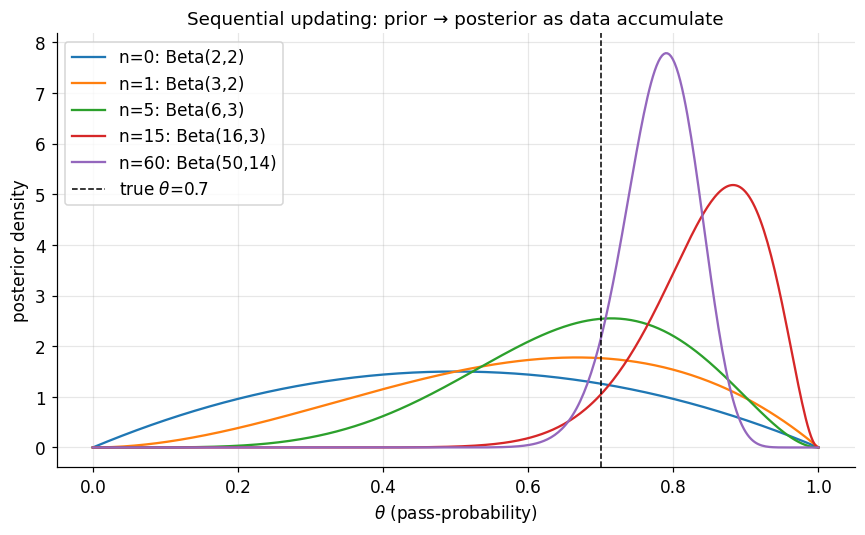

In [10]:
# Sequential Bayesian updating: watch the posterior sharpen as data arrive.
true_theta = 0.7                                  # ground truth (unknown to us)
a0, b0 = 2, 2                                      # weak prior: "probably near 0.5"
data = rng.random(60) < true_theta                # 60 pass/fail tests

theta = np.linspace(0, 1, 400)
checkpoints = [0, 1, 5, 15, 60]                    # after how many observations to plot

plt.figure(figsize=(8, 5))
for n in checkpoints:
    k = data[:n].sum()                             # passes so far
    a, b = a0 + k, b0 + (n - k)                    # <-- the entire update rule
    plt.plot(theta, stats.beta.pdf(theta, a, b),
             label=f"n={n}: Beta({a},{b})")
plt.axvline(true_theta, color="k", ls="--", lw=1, label=f"true $\\theta$={true_theta}")
plt.xlabel(r"$\theta$ (pass-probability)"); plt.ylabel("posterior density")
plt.title("Sequential updating: prior → posterior as data accumulate")
plt.legend(); plt.tight_layout(); plt.show()

Data: 48 passes out of 60 tests
  MLE (frequentist point est.) : 0.800
  Posterior mean               : 0.781
  Posterior mode / MAP         : 0.790
  95% CREDIBLE interval        : [0.673, 0.873]
  -> P(theta in that interval | data) = 0.95, literally.


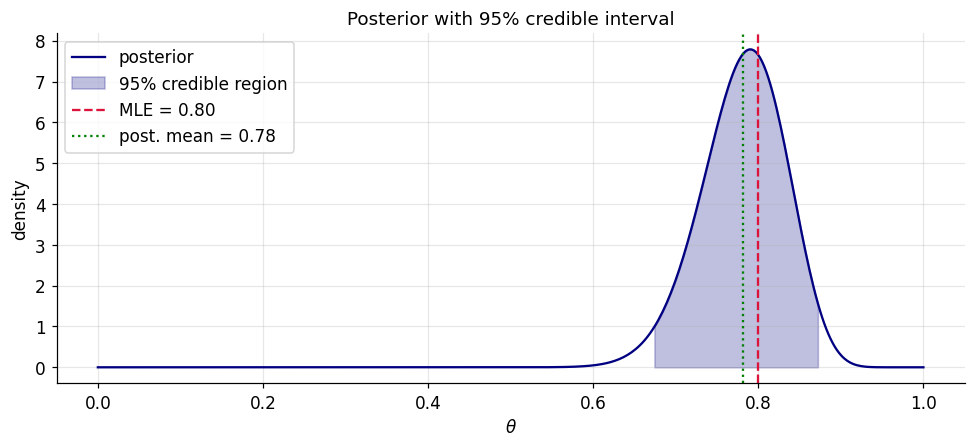

In [11]:
# Full posterior after all 60 tests: point estimates + 95% credible interval.
n = len(data); k = int(data.sum())
a, b = a0 + k, b0 + (n - k)
post = stats.beta(a, b)

mle       = k / n
post_mean = post.mean()
post_mode = (a - 1) / (a + b - 2)                  # MAP
lo, hi    = post.ppf(0.025), post.ppf(0.975)       # equal-tailed 95% credible interval

print(f"Data: {k} passes out of {n} tests")
print(f"  MLE (frequentist point est.) : {mle:.3f}")
print(f"  Posterior mean               : {post_mean:.3f}")
print(f"  Posterior mode / MAP         : {post_mode:.3f}")
print(f"  95% CREDIBLE interval        : [{lo:.3f}, {hi:.3f}]")
print(f"  -> P(theta in that interval | data) = 0.95, literally.")

theta = np.linspace(0, 1, 400)
plt.figure()
plt.plot(theta, post.pdf(theta), color="navy", label="posterior")
mask = (theta >= lo) & (theta <= hi)
plt.fill_between(theta[mask], post.pdf(theta[mask]), alpha=0.25, color="navy",
                 label="95% credible region")
plt.axvline(mle, color="crimson", ls="--", label=f"MLE = {mle:.2f}")
plt.axvline(post_mean, color="green", ls=":", label=f"post. mean = {post_mean:.2f}")
plt.xlabel(r"$\theta$"); plt.ylabel("density"); plt.title("Posterior with 95% credible interval")
plt.legend(); plt.tight_layout(); plt.show()

---
## 5.2 Worked example 2 — a noisy measurement (Normal–Normal)

**Engineering setting.** We measure a fixed physical quantity $\mu$ (e.g. a resonant frequency, a
material modulus) with an instrument of *known* noise standard deviation $\sigma$. Each reading is
$x_i = \mu + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$. We want $\mu$.

### 5.2.1 The model (another conjugate pair)

- **Likelihood:** $x_i \mid \mu \sim \mathcal{N}(\mu, \sigma^2)$.
- **Prior:** $\mu \sim \mathcal{N}(\mu_0, \tau_0^2)$ — a prior guess $\mu_0$ with uncertainty $\tau_0$.

The Normal prior is conjugate to the Normal likelihood, so the posterior is again Normal. After
observing $n$ readings with sample mean $\bar x$:

$$
\mu \mid \mathcal{D} \;\sim\; \mathcal{N}(\mu_n, \tau_n^2), \qquad
\tau_n^2 = \left(\frac{1}{\tau_0^2} + \frac{n}{\sigma^2}\right)^{-1}, \qquad
\mu_n = \tau_n^2\left(\frac{\mu_0}{\tau_0^2} + \frac{n\,\bar x}{\sigma^2}\right).
$$

Read the update in terms of **precision** $=1/\text{variance}$: **posterior precision = prior
precision + data precision.** The posterior mean $\mu_n$ is a *precision-weighted average* of the
prior guess and the data mean — the more data (or the less noise), the more the data wins.

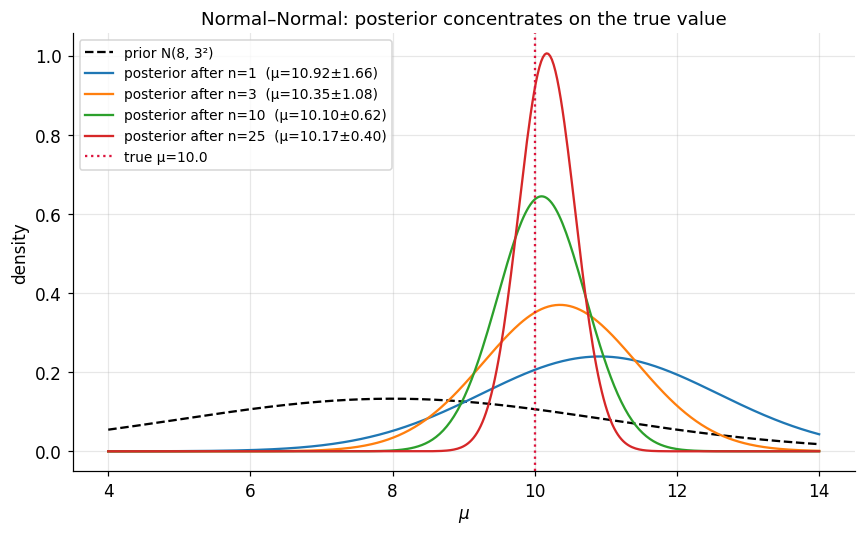

Final posterior: mu = 10.170 ± 0.396 (1 sigma)
95% credible interval: [9.393, 10.947]


In [12]:
# Bayesian estimation of an unknown mean with known measurement noise.
true_mu, sigma = 10.0, 2.0            # true value and known instrument noise
mu0, tau0      = 8.0, 3.0             # prior: "around 8, but not sure"

readings = rng.normal(true_mu, sigma, size=25)

def normal_update(mu0, tau0, x, sigma):
    n, xbar = len(x), np.mean(x)
    tau_n2 = 1.0 / (1.0/tau0**2 + n/sigma**2)
    mu_n   = tau_n2 * (mu0/tau0**2 + n*xbar/sigma**2)
    return mu_n, np.sqrt(tau_n2)

grid = np.linspace(4, 14, 400)
plt.figure(figsize=(8, 5))
plt.plot(grid, stats.norm.pdf(grid, mu0, tau0), "k--", label="prior N(8, 3²)")
for n in [1, 3, 10, 25]:
    mu_n, tau_n = normal_update(mu0, tau0, readings[:n], sigma)
    plt.plot(grid, stats.norm.pdf(grid, mu_n, tau_n),
             label=f"posterior after n={n}  (μ={mu_n:.2f}±{tau_n:.2f})")
plt.axvline(true_mu, color="crimson", ls=":", label=f"true μ={true_mu}")
plt.xlabel(r"$\mu$"); plt.ylabel("density")
plt.title("Normal–Normal: posterior concentrates on the true value")
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

mu_n, tau_n = normal_update(mu0, tau0, readings, sigma)
print(f"Final posterior: mu = {mu_n:.3f} ± {tau_n:.3f} (1 sigma)")
print(f"95% credible interval: [{mu_n-1.96*tau_n:.3f}, {mu_n+1.96*tau_n:.3f}]")

Notice the posterior starts near the prior (8) and, as readings accumulate, marches toward the true
value (10) while getting *narrower* — uncertainty shrinks like $\tau_n \sim \sigma/\sqrt{n}$, exactly
the CLT scaling


## 5.3 Worked example 3 — Bayesian linear regression (calibration)

**Engineering setting.** We calibrate a sensor: apply known loads $x$ and record outputs $y$. We
believe $y = w_0 + w_1 x + \varepsilon$ with noise $\varepsilon\sim\mathcal N(0,\sigma^2)$. Ordinary
least squares gives a *single* line. The Bayesian approach gives a *distribution over lines*, and
hence honest error bars on every prediction — vital when the calibration feeds a safety margin.

### 5.3.1 The model

Stack the data into a design matrix $\mathbf X$ (a column of ones for the intercept, a column of
$x$). With weights $\mathbf w = [w_0, w_1]^\top$:

- **Likelihood:** $\;\mathbf y \mid \mathbf w \sim \mathcal N(\mathbf X\mathbf w,\; \sigma^2 \mathbf I)$.
- **Prior:** $\;\mathbf w \sim \mathcal N(\mathbf 0,\; \alpha^{-1}\mathbf I)$ — small weights preferred
  (this is ridge/L2 regularisation in disguise).

Conjugacy (Gaussian × Gaussian) gives a **closed-form Gaussian posterior** over the weights:

$$
\mathbf w \mid \mathcal{D} \sim \mathcal N(\mathbf m,\, \mathbf S), \qquad
\mathbf S = \big(\alpha \mathbf I + \sigma^{-2}\mathbf X^\top \mathbf X\big)^{-1}, \qquad
\mathbf m = \sigma^{-2}\, \mathbf S\, \mathbf X^\top \mathbf y .
$$

### 5.3.2 The predictive distribution

For a new load $x_\star$ (row $\mathbf x_\star$) the prediction is itself Gaussian — its variance has
**two parts**: parameter uncertainty *plus* irreducible measurement noise:

$$
y_\star \mid \mathcal{D} \sim \mathcal N\!\big(\mathbf x_\star \mathbf m,\;\;
\underbrace{\mathbf x_\star \mathbf S\, \mathbf x_\star^\top}_{\text{epistemic}} +
\underbrace{\sigma^2}_{\text{aleatoric}}\big).
$$

Posterior mean weights  m = [0.932 1.884]  (true: [1. 2.] )


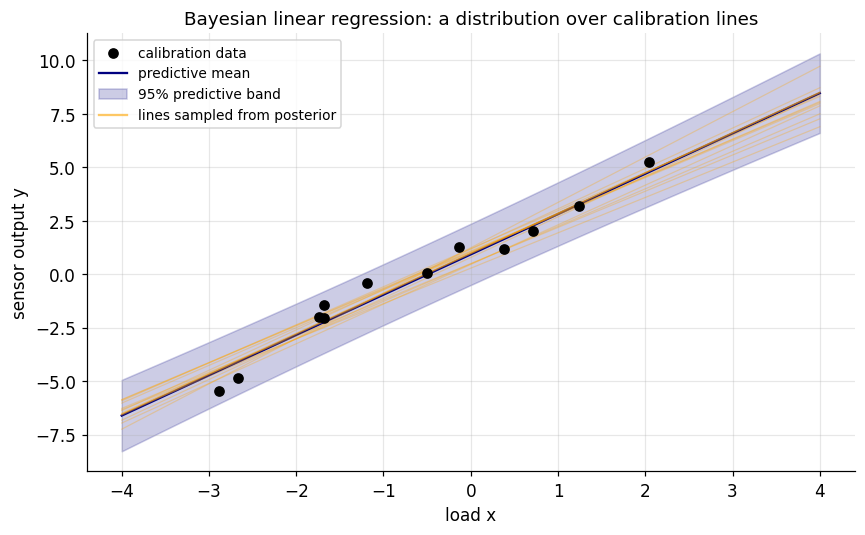

In [13]:
# Bayesian linear regression, closed form.
sigma, alpha = 0.7, 2.0                          # noise std; prior precision
w_true = np.array([1.0, 2.0])                    # true intercept, slope

x = np.sort(rng.uniform(-3, 3, size=12))         # calibration loads (few points!)
X = np.vstack([np.ones_like(x), x]).T            # design matrix, columns [1, x]
y = X @ w_true + rng.normal(0, sigma, size=len(x))

# Posterior over weights
S = np.linalg.inv(alpha*np.eye(2) + X.T @ X / sigma**2)
m = (S @ X.T @ y) / sigma**2
print("Posterior mean weights  m =", np.round(m, 3), " (true:", w_true, ")")

# Predictive distribution on a dense grid
xs = np.linspace(-4, 4, 200)
Xs = np.vstack([np.ones_like(xs), xs]).T
mean_pred = Xs @ m
var_pred  = np.einsum("ij,jk,ik->i", Xs, S, Xs) + sigma**2   # epistemic + aleatoric
std_pred  = np.sqrt(var_pred)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="k", zorder=5, label="calibration data")
plt.plot(xs, mean_pred, "navy", label="predictive mean")
plt.fill_between(xs, mean_pred-1.96*std_pred, mean_pred+1.96*std_pred,
                 alpha=0.20, color="navy", label="95% predictive band")
# a few plausible lines sampled from the posterior over weights
for w in rng.multivariate_normal(m, S, size=15):
    plt.plot(xs, Xs @ w, color="orange", alpha=0.3, lw=0.8)
plt.plot([], [], color="orange", alpha=0.6, label="lines sampled from posterior")
plt.xlabel("load x"); plt.ylabel("sensor output y")
plt.title("Bayesian linear regression: a distribution over calibration lines")
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

The band **fans out where there is little data** (the edges) and is tight where data cluster — the
model *knows what it does not know*. A single least-squares line cannot express that, and this is
precisely why Bayesian methods are prized for uncertainty quantification in engineering.

## Part 6 — Summary, Guidance & References

### What we built

1. **Probability fundamentals** — random variables, expectation/variance, the sum &
   product rules, **Bayes' theorem**, the CLT, and the Gaussian (the one distribution
   that stays Gaussian under everything we do).
2. **The probabilistic view of learning** — likelihood, **MLE = least squares**,
   **MAP = regularisation**, and why keeping the *whole posterior* beats a point
   estimate.
3. **Bayesian Linear Regression** — a closed-form posterior and predictive
   distribution, cleanly splitting **aleatoric vs epistemic** uncertainty.

### Choosing an architecture... beyond what you have learned — a practical guide

| If you have… | Consider | Why |
|--------------|----------|-----|
| A known, fixed set of features; want closed form | **Bayesian Linear Regression** | Exact, cheap, interpretable |
| Small/medium data, need calibrated UQ, don't know the basis | **Gaussian Process** ⭐ | Nonparametric, honest error bars |
| Expensive black-box to optimise | **GP + Bayesian Optimisation** | Uses uncertainty to explore |
| Large / high-dimensional / image data | **Bayesian Neural Network**, MC-Dropout, Deep Ensembles | Scales; approximate posterior |
| Only need a point prediction, huge data | Standard (non-Bayesian) ML | UQ overhead not worth it |

**The through-line:** every method above is *the same Bayesian update* — prior +
likelihood → posterior — applied to a different model class. Master the update once
and the rest is engineering.

In the next lectures we will go through Bayesian Model updating, Gaussian Process and Bayesian Optimization! 

### Key equations to remember

$$
\textbf{Bayes:}\ \ p(\theta\mid\mathcal D)\propto p(\mathcal D\mid\theta)\,p(\theta)
\qquad
\textbf{Predictive:}\ \ p(y_\*\mid\mathcal D)=\!\int p(y_\*\mid\theta)\,p(\theta\mid\mathcal D)\,d\theta
$$
$$
\textbf{Uncertainty split:}\quad \sigma^2_{\text{total}}=\underbrace{\sigma^2_{\text{noise}}}_{\text{aleatoric}}+\underbrace{\sigma^2_{\text{model}}}_{\text{epistemic}}
$$

### References

**Foundational texts**
1. C. M. Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006. — Ch. 1–2 (probability), Ch. 3 (Bayesian linear regression). The source for the BLR equations used in Part 3.
2. K. P. Murphy, *Probabilistic Machine Learning: An Introduction* (2022) & *Advanced Topics* (2023), MIT Press. Free PDFs at [probml.github.io](https://probml.github.io/pml-book/). — Modern, comprehensive.
3. D. J. C. MacKay, *Information Theory, Inference, and Learning Algorithms*, CUP, 2003. Free at [inference.org.uk/mackay/itila](https://www.inference.org.uk/mackay/itila/). — Superb on the "Occam's razor" view of the evidence.

**Probability & statistics background**
4. A. Papoulis & S. U. Pillai, *Probability, Random Variables and Stochastic Processes*, 4th ed., McGraw-Hill, 2002. — Engineering-oriented probability reference.
5. E. T. Jaynes, *Probability Theory: The Logic of Science*, CUP, 2003. — Probability as extended logic.

**Engineering applications / uncertainty quantification**
6. R. Ghanem, D. Higdon & H. Owhadi (eds.), *Handbook of Uncertainty Quantification*, Springer, 2017.
7. M. C. Kennedy & A. O'Hagan, "Bayesian calibration of computer models," *J. R. Statist. Soc. B*, 63(3), 425–464, 2001. — The reference for calibrating physics models against data.

**Software**
10. scikit-learn `gaussian_process` module — used in Parts 4–5. For scalable / deep probabilistic models see **GPyTorch**, **GPflow**, **PyMC**, and **NumPyro**.

---